In [ ]:
import pandas as pd

In [7]:
pwd

'/Users/brylew/github/brave-childcare-godot'

In [40]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Define file paths - update these to match your output file names
output_dir = Path('Sample Inputs/')
plot_dir = Path('analysis/plots/')
plot_dir.mkdir(parents=True, exist_ok=True)
exposure_file = output_dir / 'output_childcare_people_movement_exposure.json'
person_file = output_dir / 'persons_childcare_pop.json'

output_suffix = 'flat6-sched'

print(f"Looking for exposure file at: {exposure_file}")
print(f"Looking for person file at: {person_file}")
print(f"Files exist: exposure={exposure_file.exists()}, person={person_file.exists()}")

Looking for exposure file at: Sample Inputs/output_childcare_people_movement_exposure.json
Looking for person file at: Sample Inputs/persons_childcare_pop.json
Files exist: exposure=True, person=True


In [41]:
# Load exposure data from JSON file
exposure_rows = []
if exposure_file.exists():
    with open(exposure_file, 'r') as f:
        for line in f:
            if line.strip():
                row = json.loads(line)
                exposure_rows.append(row)

exposure_df = pd.DataFrame(exposure_rows)
print(f"Loaded {len(exposure_df)} exposure records")
print(f"Columns: {list(exposure_df.columns)}")
print(f"\nFirst few rows:")
print(exposure_df.head())

Loaded 1250 exposure records
Columns: ['cumulative_viral_exposure', 'event', 'pid', 'sample_count', 'time']

First few rows:
   cumulative_viral_exposure            event  pid  sample_count          time
0               15422.577080  person_exposure  101            18  24633.333333
1               15422.577080  person_exposure  102            18  24633.333333
2               13998.262943  person_exposure  103            18  24633.333333
3                3767.984329  person_exposure  104            13  24633.333333
4               15422.577080  person_exposure  105            18  24633.333333


In [42]:
# Load person data to get role/type information
person_data = []
if person_file.exists():
    with open(person_file, 'r') as f:
        person_data = json.load(f)

# Create a mapping from pid to role
pid_to_role = {}
for person in person_data:
    pid_to_role[str(person.get('pid', ''))] = person.get('role', 'unknown')

print(f"Loaded {len(pid_to_role)} persons")
print(f"Roles found: {set(pid_to_role.values())}")

# Add role column to exposure dataframe
if exposure_df is not None and len(exposure_df) > 0:
    exposure_df['role'] = exposure_df['pid'].map(pid_to_role)
    print(f"\nExposure data with roles:")
    print(exposure_df[['pid', 'role', 'cumulative_viral_exposure', 'sample_count']].head(10))

Loaded 50 persons
Roles found: {'older toddlers', 'infants', 'preschoolers', 'providers', 'younger toddlers', 'floaters'}

Exposure data with roles:
   pid              role  cumulative_viral_exposure  sample_count
0  101           infants               15422.577080            18
1  102           infants               15422.577080            18
2  103           infants               13998.262943            18
3  104           infants                3767.984329            13
4  105           infants               15422.577080            18
5  106           infants               15422.577080            18
6  201  younger toddlers               15422.577080            18
7  202  younger toddlers               15422.577080            18
8  203  younger toddlers               15422.577080            18
9  204  younger toddlers               15422.577080            18


In [43]:
# Get final cumulative exposure per person (last value for each pid)
final_exposure = exposure_df.sort_values('time').drop_duplicates('pid', keep='last')
final_exposure = final_exposure.sort_values('cumulative_viral_exposure', ascending=False)

print(f"Final exposure statistics by role:")
for role in sorted(final_exposure['role'].unique()):
    role_data = final_exposure[final_exposure['role'] == role]
    print(f"\n{role}:")
    print(f"  Count: {len(role_data)}")
    print(f"  Mean exposure: {role_data['cumulative_viral_exposure'].mean():.2f}")
    print(f"  Max exposure: {role_data['cumulative_viral_exposure'].max():.2f}")
    print(f"  Min exposure: {role_data['cumulative_viral_exposure'].min():.2f}")

Final exposure statistics by role:

floaters:
  Count: 2
  Mean exposure: 280037.90
  Max exposure: 285164.45
  Min exposure: 274911.36

infants:
  Count: 6
  Mean exposure: 265049.02
  Max exposure: 300301.01
  Min exposure: 239134.32

older toddlers:
  Count: 10
  Mean exposure: 205318.30
  Max exposure: 367212.99
  Min exposure: 80697.69

preschoolers:
  Count: 16
  Mean exposure: 348509.65
  Max exposure: 461945.21
  Min exposure: 256614.42

providers:
  Count: 8
  Mean exposure: 272176.54
  Max exposure: 309453.90
  Min exposure: 238645.54

younger toddlers:
  Count: 8
  Mean exposure: 339847.15
  Max exposure: 413690.44
  Min exposure: 241526.54


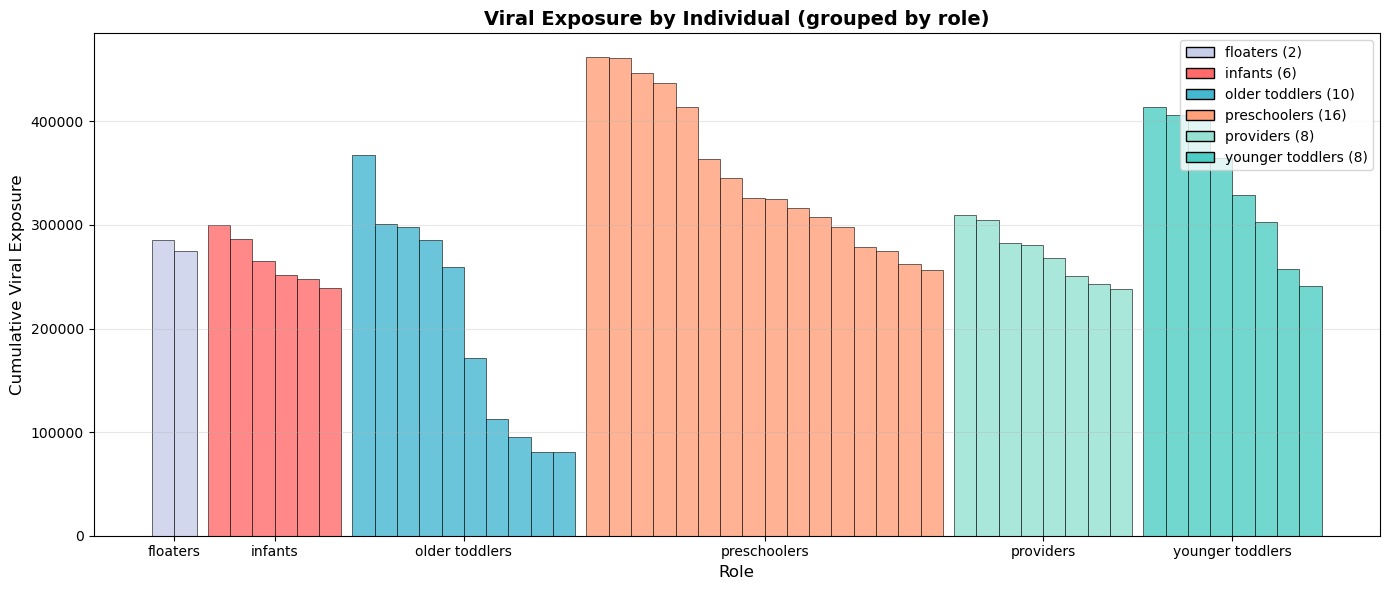


Total individuals plotted: 50
Saved: analysis/plots/01_exposure_by_individual_flat6-sched.png


In [44]:
# Create color palette for roles
role_colors = {
    'infants': '#FF6B6B',
    'younger toddlers': '#4ECDC4',
    'older toddlers': '#45B7D1',
    'preschoolers': '#FFA07A',
    'providers': '#95E1D3',
    'floaters': '#C7CEEA',
    'unknown': '#CCCCCC'
}

# Get unique roles and their counts
roles = sorted(final_exposure['role'].unique())
role_counts = {role: len(final_exposure[final_exposure['role'] == role]) for role in roles}

# Plot cumulative exposure by PID with color by role - grouped by role
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 6))

x_pos = 0
x_tick_positions = []
x_tick_labels = []
bar_width = 0.6

# Plot each role's people as a group
for role in roles:
    role_data = final_exposure[final_exposure['role'] == role]
    color = role_colors.get(role, '#CCCCCC')
    num_in_role = len(role_data)
    
    # Store the starting position for this role's group
    role_start = x_pos
    
    # Plot each person in this role as a side-by-side bar
    for idx, (_, row) in enumerate(role_data.iterrows()):
        ax.bar(x_pos, row['cumulative_viral_exposure'], 
               width=bar_width,
               color=color,
               alpha=0.8,
               edgecolor='black',
               linewidth=0.5)
        x_pos += bar_width
    
    # Calculate the center of this role's group for the tick label
    role_center = role_start + (num_in_role - 1) * bar_width / 2
    x_tick_positions.append(role_center)
    x_tick_labels.append(role)
    
    # Add space between role groups
    x_pos += 0.3

ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels)
ax.set_xlabel('Role', fontsize=12)
ax.set_ylabel('Cumulative Viral Exposure', fontsize=12)
ax.set_title('Viral Exposure by Individual (grouped by role)', fontsize=14, fontweight='bold')

# Create legend with role names and counts
legend_elements = [Patch(facecolor=role_colors.get(role, '#CCCCCC'), 
                         edgecolor='black', 
                         label=f"{role} ({role_counts[role]})")
                   for role in roles]
ax.legend(handles=legend_elements, loc='upper right', frameon=True)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir / f'01_exposure_by_individual_{output_suffix}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal individuals plotted: {len(final_exposure)}")
print(f"Saved: {plot_dir / f'01_exposure_by_individual_{output_suffix}.png'}")

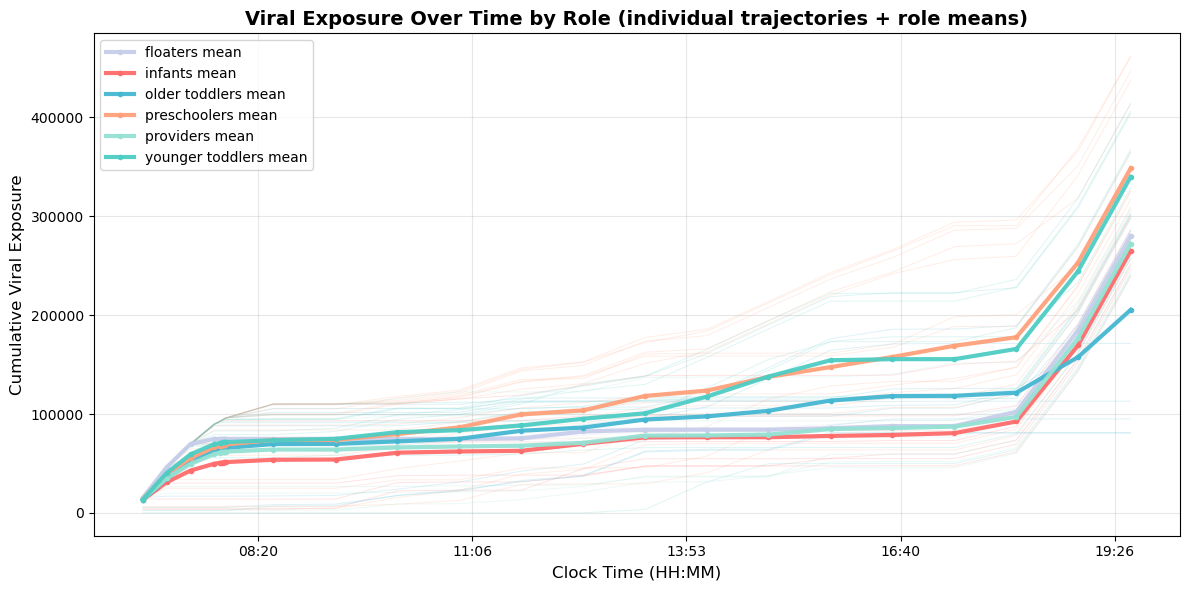

Saved: analysis/plots/02_exposure_over_time_flat6-sched.png


In [45]:
# Plot cumulative exposure over time with individual trajectories + role means
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 6))

for role in sorted(exposure_df['role'].dropna().unique()):
    role_data = exposure_df[exposure_df['role'] == role].sort_values(['pid', 'time'])
    color = role_colors.get(role, '#CCCCCC')

    # Individual trajectories: thin and transparent so the mean remains dominant.
    for pid, pid_data in role_data.groupby('pid'):
        ax.plot(
            pid_data['time'],
            pid_data['cumulative_viral_exposure'],
            color=color,
            linewidth=0.7,
            alpha=0.18,
            zorder=1
        )

    # Role mean trajectory: thicker and more opaque for emphasis.
    time_avg = role_data.groupby('time')['cumulative_viral_exposure'].mean()
    ax.plot(
        time_avg.index,
        time_avg.values,
        label=f"{role} mean",
        linewidth=3.0,
        color=color,
        alpha=0.95,
        marker='o',
        markersize=3,
        zorder=3
    )

# Format x-axis seconds as HH:MM clock time.
def _seconds_to_clock(x, _pos):
    total_seconds = int(round(x))
    hours = (total_seconds // 3600) % 24
    minutes = (total_seconds % 3600) // 60
    return f"{hours:02d}:{minutes:02d}"

ax.xaxis.set_major_formatter(FuncFormatter(_seconds_to_clock))

ax.set_xlabel('Clock Time (HH:MM)', fontsize=12)
ax.set_ylabel('Cumulative Viral Exposure', fontsize=12)
ax.set_title('Viral Exposure Over Time by Role (individual trajectories + role means)', fontsize=14, fontweight='bold')
ax.legend(frameon=True, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir / f'02_exposure_over_time_{output_suffix}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_dir / f'02_exposure_over_time_{output_suffix}.png'}")

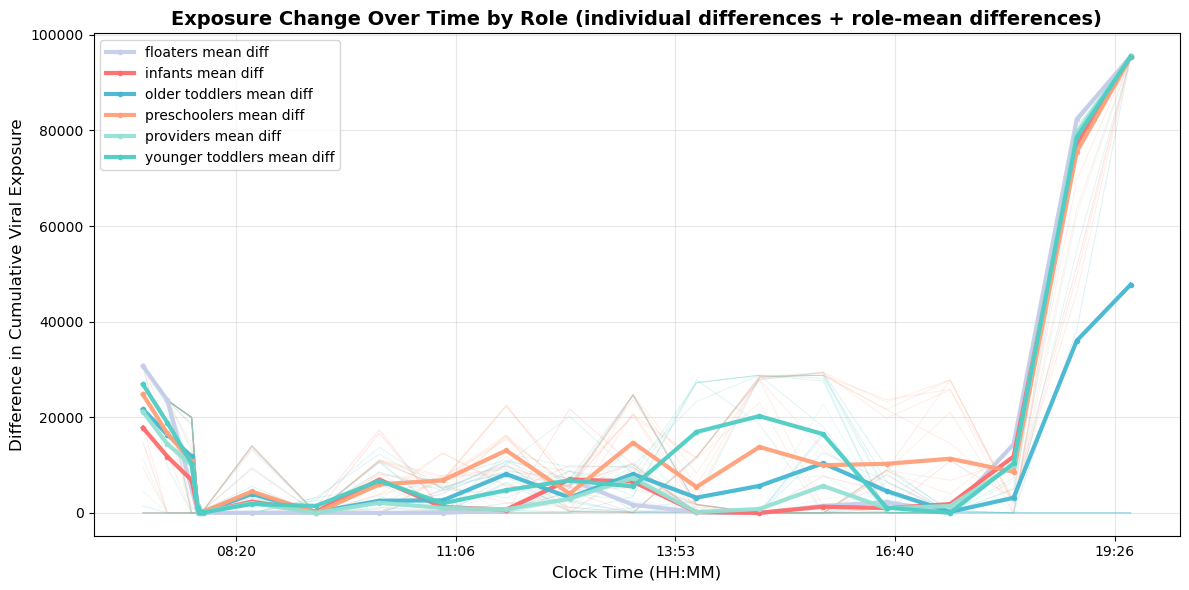

Saved: analysis/plots/03_exposure_differences_flat6-sched.png


In [46]:
# Plot first differences in cumulative exposure over time
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 6))

for role in sorted(exposure_df['role'].dropna().unique()):
    role_data = exposure_df[exposure_df['role'] == role].sort_values(['pid', 'time']).copy()
    color = role_colors.get(role, '#CCCCCC')

    # Per-person first differences in cumulative exposure.
    role_data['delta_exposure'] = role_data.groupby('pid')['cumulative_viral_exposure'].diff()

    # Individual trajectories: thin and transparent.
    for pid, pid_data in role_data.groupby('pid'):
        pid_diff = pid_data.dropna(subset=['delta_exposure'])
        ax.plot(
            pid_diff['time'],
            pid_diff['delta_exposure'],
            color=color,
            linewidth=0.7,
            alpha=0.18,
            zorder=1
        )

    # Role mean of first differences: thicker and more opaque.
    role_mean_diff = role_data.groupby('time')['delta_exposure'].mean().dropna()
    ax.plot(
        role_mean_diff.index,
        role_mean_diff.values,
        label=f"{role} mean diff",
        linewidth=3.0,
        color=color,
        alpha=0.95,
        marker='o',
        markersize=3,
        zorder=3
    )

# Format x-axis seconds as HH:MM clock time.
def _seconds_to_clock(x, _pos):
    total_seconds = int(round(x))
    hours = (total_seconds // 3600) % 24
    minutes = (total_seconds % 3600) // 60
    return f"{hours:02d}:{minutes:02d}"

ax.xaxis.set_major_formatter(FuncFormatter(_seconds_to_clock))

ax.set_xlabel('Clock Time (HH:MM)', fontsize=12)
ax.set_ylabel('Difference in Cumulative Viral Exposure', fontsize=12)
ax.set_title('Exposure Change Over Time by Role (individual differences + role-mean differences)', fontsize=14, fontweight='bold')
ax.legend(frameon=True, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir / f'03_exposure_differences_{output_suffix}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_dir / f'03_exposure_differences_{output_suffix}.png'}")

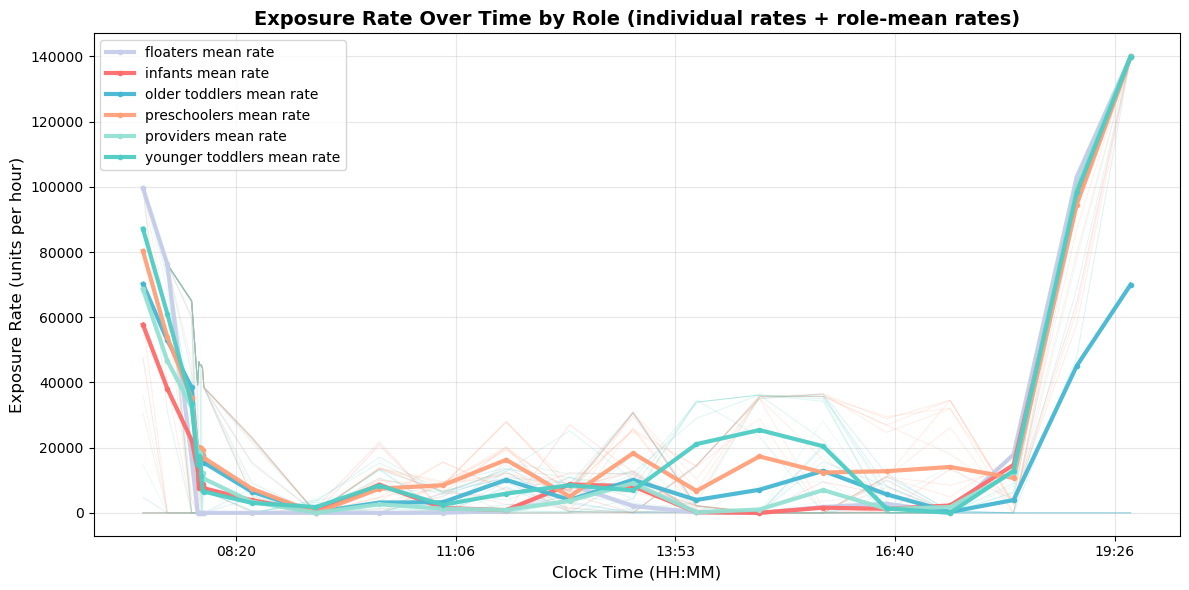

Saved: analysis/plots/04_exposure_rate_flat6-sched.png


In [47]:
# Plot exposure change rate over time (delta exposure per hour)
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 6))

for role in sorted(exposure_df['role'].dropna().unique()):
    role_data = exposure_df[exposure_df['role'] == role].sort_values(['pid', 'time']).copy()
    color = role_colors.get(role, '#CCCCCC')

    # Compute per-person differences and elapsed time.
    role_data['delta_exposure'] = role_data.groupby('pid')['cumulative_viral_exposure'].diff()
    role_data['delta_time_s'] = role_data.groupby('pid')['time'].diff()

    # Rate in exposure units per hour.
    role_data['exposure_rate_per_hour'] = np.where(
        role_data['delta_time_s'] > 0,
        role_data['delta_exposure'] * 3600.0 / role_data['delta_time_s'],
        np.nan
    )

    # Individual rates: thin and transparent.
    for pid, pid_data in role_data.groupby('pid'):
        pid_rate = pid_data.dropna(subset=['exposure_rate_per_hour'])
        ax.plot(
            pid_rate['time'],
            pid_rate['exposure_rate_per_hour'],
            color=color,
            linewidth=0.7,
            alpha=0.18,
            zorder=1
        )

    # Role-mean rate: thicker and more opaque.
    role_mean_rate = role_data.groupby('time')['exposure_rate_per_hour'].mean().dropna()
    ax.plot(
        role_mean_rate.index,
        role_mean_rate.values,
        label=f"{role} mean rate",
        linewidth=3.0,
        color=color,
        alpha=0.95,
        marker='o',
        markersize=3,
        zorder=3
    )

# Format x-axis seconds as HH:MM clock time.
def _seconds_to_clock(x, _pos):
    total_seconds = int(round(x))
    hours = (total_seconds // 3600) % 24
    minutes = (total_seconds % 3600) // 60
    return f"{hours:02d}:{minutes:02d}"

ax.xaxis.set_major_formatter(FuncFormatter(_seconds_to_clock))

ax.set_xlabel('Clock Time (HH:MM)', fontsize=12)
ax.set_ylabel('Exposure Rate (units per hour)', fontsize=12)
ax.set_title('Exposure Rate Over Time by Role (individual rates + role-mean rates)', fontsize=14, fontweight='bold')
ax.legend(frameon=True, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir / f'04_exposure_rate_{output_suffix}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_dir / f'04_exposure_rate_{output_suffix}.png'}")

Looking for room file at: Sample Inputs/output_childcare_rooms.json


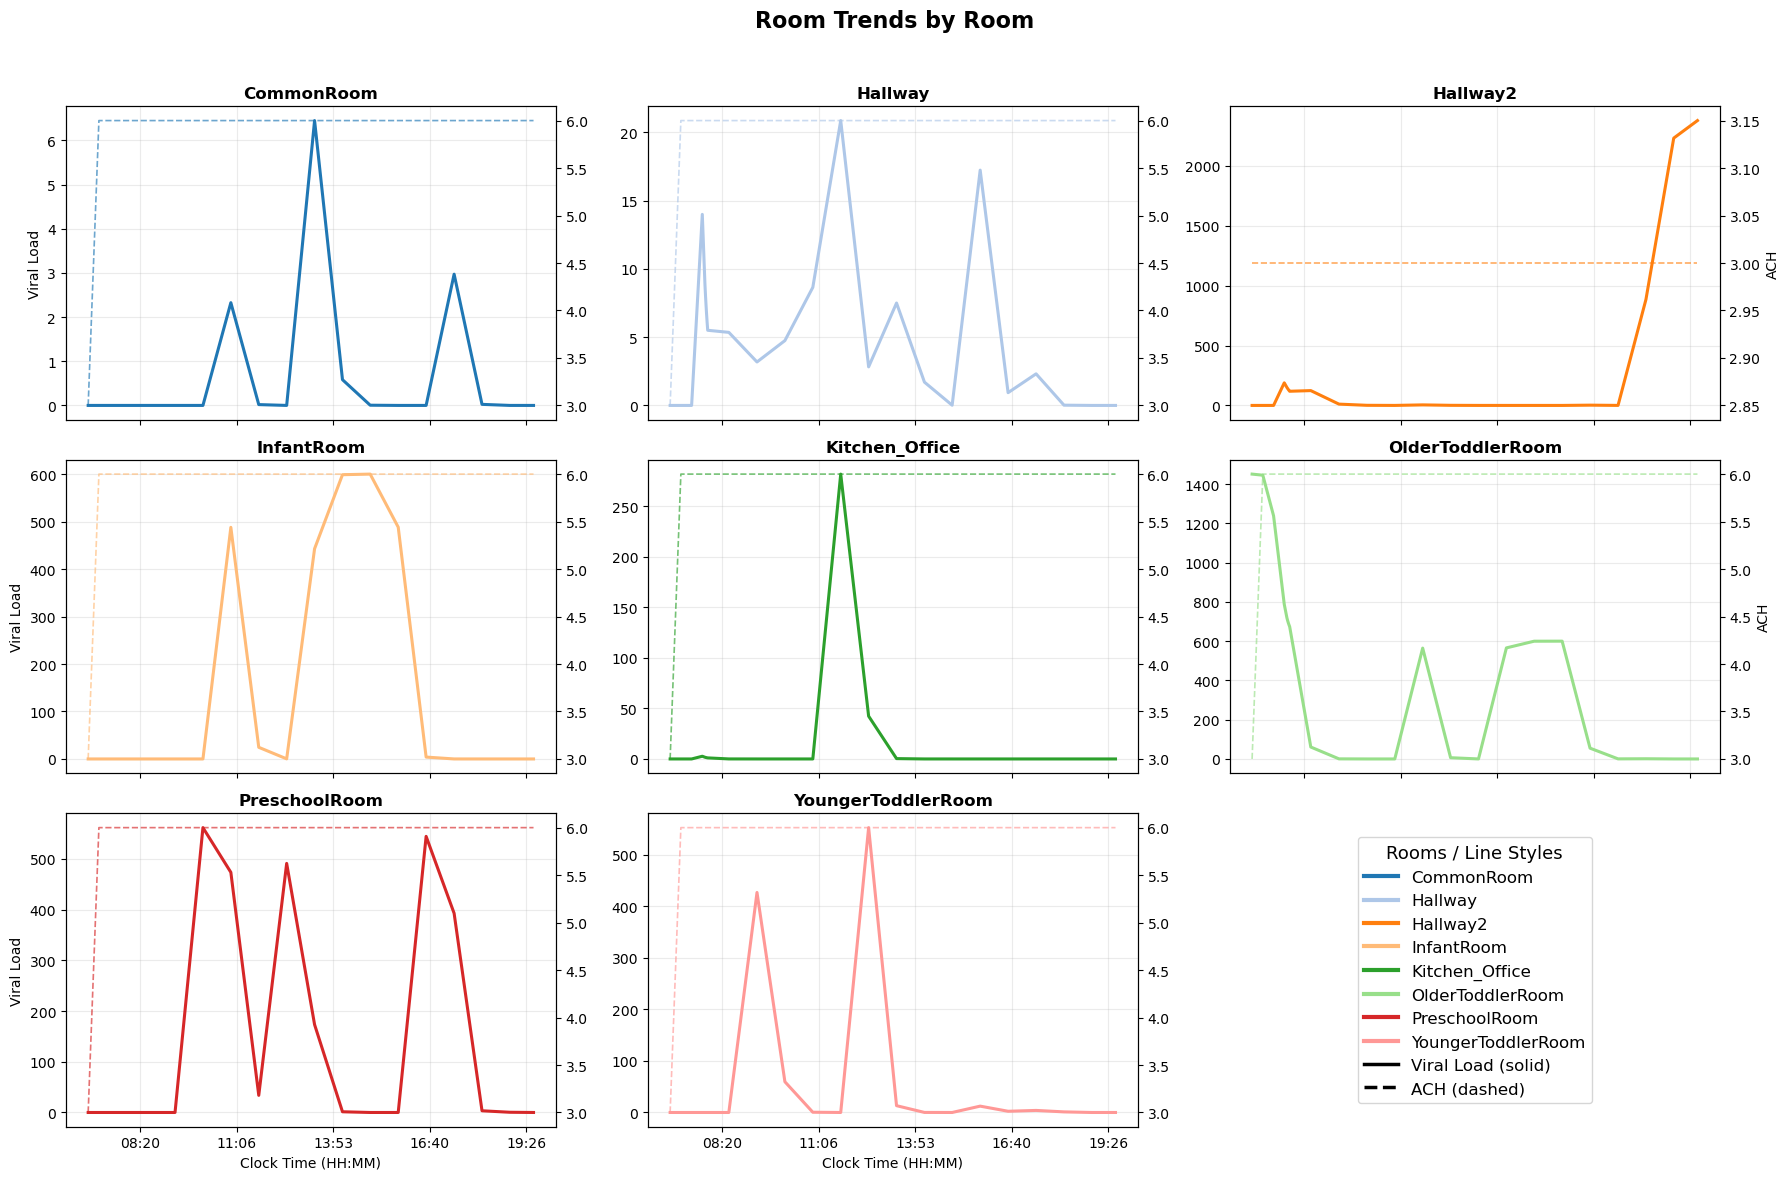

Loaded 200 room_state records across 8 rooms
Saved: analysis/plots/05_room_trends_flat6-sched.png


In [48]:
# Plot room trajectories as a 3x3 grid (8 rooms + legend panel)
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

room_file = output_dir / 'output_childcare_rooms.json'
print(f"Looking for room file at: {room_file}")

room_rows = []
if room_file.exists():
    with open(room_file, 'r') as f:
        for line in f:
            if line.strip():
                room_rows.append(json.loads(line))

room_df = pd.DataFrame(room_rows)
if room_df.empty:
    print('No room data loaded. Check room file path.')
else:
    if 'event' in room_df.columns:
        room_df = room_df[room_df['event'] == 'room_state'].copy()

    room_df['time'] = pd.to_numeric(room_df['time'], errors='coerce')
    room_df['viral_load'] = pd.to_numeric(room_df['viral_load'], errors='coerce')
    room_df['ach'] = pd.to_numeric(room_df['ach'], errors='coerce')
    room_df = room_df.dropna(subset=['time', 'viral_load', 'ach']).sort_values(['room_name', 'time'])

    room_names = sorted(room_df['room_name'].dropna().unique())
    cmap = plt.get_cmap('tab20')
    room_color_map = {name: cmap(i % 20) for i, name in enumerate(room_names)}

    fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
    axes_flat = axes.flatten()

    # Format x-axis seconds as HH:MM clock time.
    def _seconds_to_clock(x, _pos):
        total_seconds = int(round(x))
        hours = (total_seconds // 3600) % 24
        minutes = (total_seconds % 3600) // 60
        return f"{hours:02d}:{minutes:02d}"

    # Plot each room in its own subplot (first 8 slots).
    for i, room_name in enumerate(room_names[:8]):
        ax = axes_flat[i]
        ax2 = ax.twinx()
        room_data = room_df[room_df['room_name'] == room_name]
        color = room_color_map[room_name]

        ax.plot(
            room_data['time'],
            room_data['viral_load'],
            color=color,
            linewidth=2.2,
            alpha=1.0,
            linestyle='-',
            zorder=3
        )

        ax2.plot(
            room_data['time'],
            room_data['ach'],
            color=color,
            linewidth=1.2,
            alpha=0.65,
            linestyle='--',
            zorder=3
        )

        ax.set_title(room_name, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_major_formatter(FuncFormatter(_seconds_to_clock))

        # Left axis label only on first column for readability.
        if i % 3 == 0:
            ax.set_ylabel('Viral Load')

        # Right axis label only on last column for readability.
        if i % 3 == 2:
            ax2.set_ylabel('ACH')

    # Use final subplot (9th) as legend/key panel.
    legend_ax = axes_flat[8]
    legend_ax.axis('off')

    room_handles = [
        Line2D([0], [0], color=room_color_map[name], lw=3.0, label=name)
        for name in room_names[:8]
    ]
    style_handles = [
        Line2D([0], [0], color='black', lw=2.5, ls='-', label='Viral Load (solid)'),
        Line2D([0], [0], color='black', lw=2.5, ls='--', label='ACH (dashed)')
    ]

    legend_ax.legend(
        handles=room_handles + style_handles,
        loc='center',
        frameon=True,
        title='Rooms / Line Styles',
        fontsize=12,
        title_fontsize=13
    )

    # Bottom row x-labels.
    for idx in [6, 7]:
        axes_flat[idx].set_xlabel('Clock Time (HH:MM)')

    plt.suptitle('Viral Load by Room', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
    plt.savefig(plot_dir / f'05_room_trends_{output_suffix}.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Loaded {len(room_df)} room_state records across {len(room_names)} rooms")
    print(f"Saved: {plot_dir / f'05_room_trends_{output_suffix}.png'}")

In [49]:
# Summary table of final exposures
summary_table = final_exposure[['pid', 'role', 'cumulative_viral_exposure', 'sample_count']].copy()
summary_table = summary_table.rename(columns={
    'pid': 'Person ID',
    'role': 'Role',
    'cumulative_viral_exposure': 'Cumulative Exposure',
    'sample_count': 'Samples'
})
summary_table['Cumulative Exposure'] = summary_table['Cumulative Exposure'].round(2)

print("Top 20 individuals by cumulative viral exposure:")
print(summary_table.head(20).to_string(index=False))

Top 20 individuals by cumulative viral exposure:
Person ID             Role  Cumulative Exposure  Samples
      401     preschoolers            461945.21      547
      405     preschoolers            461241.84      546
      403     preschoolers            446699.70      533
      408     preschoolers            436902.29      548
      407     preschoolers            413849.75      525
      204 younger toddlers            413690.44      466
      203 younger toddlers            406021.50      497
      206 younger toddlers            403973.18      456
      309   older toddlers            367212.99      513
      207 younger toddlers            364993.03      477
      411     preschoolers            363982.91      547
      414     preschoolers            345539.36      535
      208 younger toddlers            328498.27      444
      404     preschoolers            325845.50      554
      402     preschoolers            324914.57      515
      416     preschoolers            3